In [4]:
import os, sys

os.chdir(os.path.expanduser("~/QIAO0042/models/acv/facemask/"))
sys.path.insert(0, os.getcwd())
print("CWD:", os.getcwd())

CWD: /scratch-share/QIAO0042/models/acv/facemask


In [5]:
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from unet import UNet
from palette import NUM_CLASSES
from dataset import FaceParsingDataset

# -----------------------------------------------------------------------
# Output palette: standard VOC-style, indices 0-15 are fixed, the rest
# fall back to greyscale (index == grey level).
# Pixel values in saved PNGs = class indices (0-18), NOT RGB colours.
# -----------------------------------------------------------------------
PALETTE = np.array([[i, i, i] for i in range(256)], dtype=np.uint8)
PALETTE[:16] = np.array([
    [0,   0,   0],    # 0  background
    [128, 0,   0],    # 1  skin
    [0,   128, 0],    # 2  nose
    [128, 128, 0],    # 3  eye_g
    [0,   0,   128],  # 4  l_eye
    [128, 0,   128],  # 5  r_eye
    [0,   128, 128],  # 6  l_brow
    [128, 128, 128],  # 7  r_brow
    [64,  0,   0],    # 8  l_ear
    [191, 0,   0],    # 9  r_ear
    [64,  128, 0],    # 10 mouth
    [191, 128, 0],    # 11 u_lip
    [64,  0,   128],  # 12 l_lip
    [191, 0,   128],  # 13 hair
    [64,  128, 128],  # 14 hat
    [191, 128, 128],  # 15 ear_r
], dtype=np.uint8)


def save_palette_png(label_hw: np.ndarray, path: str) -> None:
    """
    Save a (H, W) class-index array as a palette-mode PNG.
    Pixel value == class index (0-18).  The palette controls display colour only.
    """
    img = Image.fromarray(label_hw.astype(np.uint8), mode="P")
    img.putpalette(PALETTE.reshape(-1).tolist())
    img.save(path)

In [6]:
ckpt_path = "checkpoints/full_best.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt   = torch.load(ckpt_path, map_location=device, weights_only=False)
cfg    = ckpt["config"]

from unet import UNetV2
model = UNetV2(num_classes=cfg["num_classes"], base=cfg["base_width"],
               dropout=cfg.get("dropout", 0.0)).to(device)

# torch.compile prefixes all keys with "_orig_mod." — strip it before loading
def strip_compile_prefix(state_dict):
    return {k.replace("_orig_mod.", "", 1): v for k, v in state_dict.items()}

model.load_state_dict(strip_compile_prefix(ckpt["model"]))

# Load EMA shadow weights (smoothed weights → better predictions)
if "ema_shadow" in ckpt:
    ema_shadow = strip_compile_prefix(ckpt["ema_shadow"])
    for name, param in model.named_parameters():
        if name in ema_shadow:
            param.data.copy_(ema_shadow[name])
    print("Loaded EMA shadow weights")

model.eval()
print(f"Checkpoint : {ckpt_path}")
print(f"Epoch      : {ckpt['epoch']}")
print(f"Model      : UNetV2(base={cfg['base_width']}, dropout={cfg.get('dropout', 0.0)})")
print(f"Device     : {device}")


Loaded EMA shadow weights
Checkpoint : checkpoints/full_best.pt
Epoch      : 100
Model      : UNetV2(base=23, dropout=0.3)
Device     : cuda


In [7]:
# --- TTA: average softmax(original) + softmax(flipped + label-swapped) ---
FLIP_PAIRS = [(4, 5), (6, 7), (8, 9)]  # l_eye↔r_eye, l_brow↔r_brow, l_ear↔r_ear


@torch.no_grad()
def tta_predict(model, imgs, device):
    """
    Test-time augmentation: average predictions from original and H-flipped input.
    The flipped logits have their spatial W-axis flipped back and laterally-paired
    class channels swapped so both branches are semantically aligned before averaging.
    """
    with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
        logits_orig = model(imgs)
        logits_flip = model(torch.flip(imgs, dims=[-1]))   # forward on H-flipped input

    # flip spatial axis back so predictions align with original orientation
    logits_flip = torch.flip(logits_flip, dims=[-1])

    # swap paired class channels (l/r labels must be exchanged after spatial flip)
    logits_flip_swapped = logits_flip.clone()
    for a, b in FLIP_PAIRS:
        logits_flip_swapped[:, a] = logits_flip[:, b]
        logits_flip_swapped[:, b] = logits_flip[:, a]

    # average softmax probabilities and return class predictions
    probs = (torch.softmax(logits_orig, dim=1) +
             torch.softmax(logits_flip_swapped, dim=1)) * 0.5
    return probs.argmax(dim=1)   # (B, H, W) — class indices


# --- run inference on val/images, save palette PNGs to val/predictions ---
out_dir = "val/predictions"
os.makedirs(out_dir, exist_ok=True)

val_ds     = FaceParsingDataset("val/images", mask_dir=None, augment=None)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

saved = 0
with torch.no_grad():
    for imgs, fnames in val_loader:
        imgs = imgs.to(device, non_blocking=True)
        preds = tta_predict(model, imgs, device).cpu().numpy()  # (B, H, W)

        for pred, fname in zip(preds, fnames):
            out_path = os.path.join(out_dir, Path(fname).stem + ".png")
            save_palette_png(pred, out_path)
            saved += 1

print(f"Saved {saved} predictions  →  {out_dir}/  (TTA enabled)")

# quick format check on one file
sample = Image.open(os.path.join(out_dir, Path(val_ds.img_paths[0].name).stem + ".png"))
arr    = np.array(sample)
print(f"Image mode  : {sample.mode}")            # must be 'P'
print(f"Pixel dtype : {arr.dtype}")              # uint8
print(f"Value range : {arr.min()} – {arr.max()}")   # must be 0-18, not 0-255

Loaded 100 samples from val/images
Saved 100 predictions  →  val/predictions/  (TTA enabled)
Image mode  : P
Pixel dtype : uint8
Value range : 0 – 18


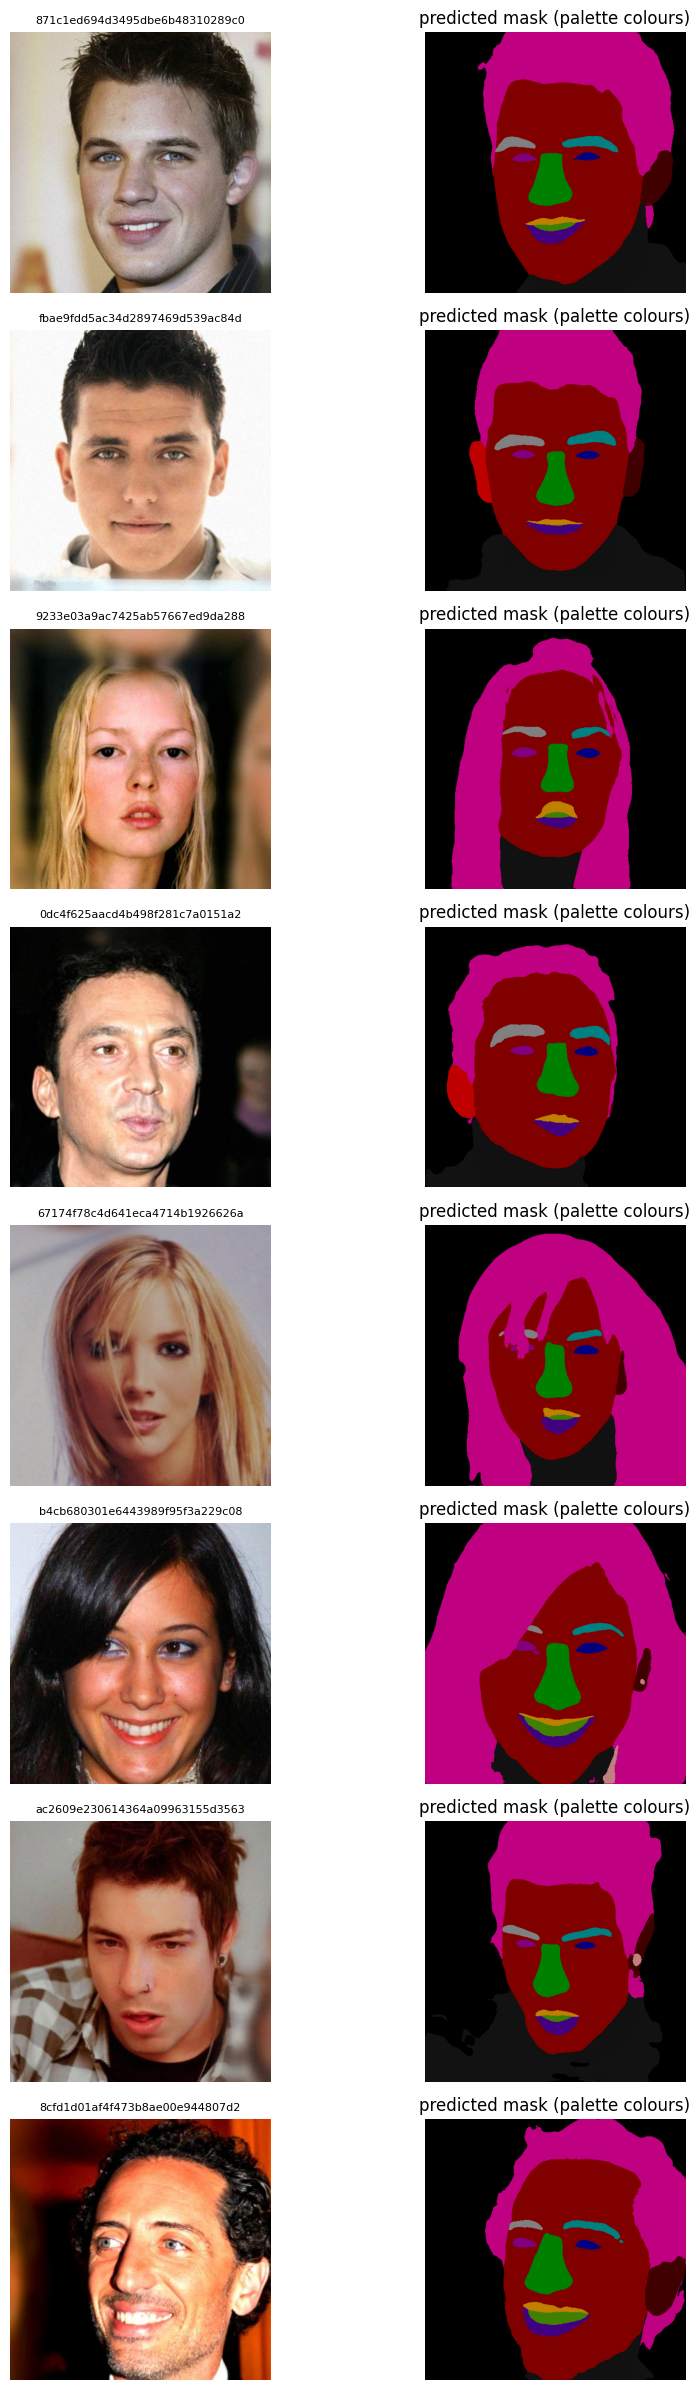

In [8]:
# --- visualise 8 random val samples (input image | palette-coloured prediction) ---
import random
random.seed(0)

n_show  = 8
indices = random.sample(range(len(val_ds)), n_show)
fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 3))

for row, idx in enumerate(indices):
    img_tensor, fname = val_ds[idx]
    img_np    = img_tensor.permute(1, 2, 0).numpy()

    pred_path = os.path.join(out_dir, Path(fname).stem + ".png")
    # convert("RGB") applies the palette so matplotlib sees colours, not grey indices
    pred_rgb  = np.array(Image.open(pred_path).convert("RGB"))

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(Path(fname).name[:30], fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(pred_rgb)
    axes[row, 1].set_title("predicted mask (palette colours)")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [12]:
import shutil
import zipfile

old_dir = out_dir
new_dir = "val/masks"

# Rename val/predictions -> val/masks (if needed)
if os.path.abspath(old_dir) != os.path.abspath(new_dir):
    if os.path.exists(new_dir):
        shutil.rmtree(new_dir)
    os.rename(old_dir, new_dir)

out_dir = new_dir  # keep notebook variable consistent

# Create val.zip with only val/masks/*
zip_path = "val.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(out_dir):
        for f in files:
            full_path = os.path.join(root, f)
            zf.write(full_path, arcname=os.path.relpath(full_path, start="."))

print(f"Using masks dir: {out_dir}")
print(f"Created: {zip_path} (contains only val/masks)")

Using masks dir: val/masks
Created: val.zip (contains only val/masks)


In [13]:
if not os.path.exists(zip_path):
    print(f"Not found: {zip_path}")
else:
    with zipfile.ZipFile(zip_path, "r") as zf:
        members = sorted(zf.namelist())

    print(f"Archive: {zip_path}")
    print(f"Total entries: {len(members)}\n")

    # Build a simple tree
    tree = {}
    for path in members:
        parts = [p for p in path.split("/") if p]
        node = tree
        for part in parts:
            node = node.setdefault(part, {})

    def print_tree(node, prefix=""):
        keys = sorted(node.keys())
        for i, key in enumerate(keys):
            is_last = i == len(keys) - 1
            connector = "└── " if is_last else "├── "
            print(prefix + connector + key)
            extension = "    " if is_last else "│   "
            print_tree(node[key], prefix + extension)

    print_tree(tree)

Archive: val.zip
Total entries: 100

└── val
    └── masks
        ├── 00f3e45703824ae2a83b96d5675b8e35.png
        ├── 037fe072b77047e3b3e0b7d723482188.png
        ├── 082a14e5d075482ea686189040b251dc.png
        ├── 0a4fdac4e7f448718c42f34a5422aee2.png
        ├── 0c5d8f0543f84f9cb8c7ed3216e2b306.png
        ├── 0dc4f625aacd4b498f281c7a0151a25a.png
        ├── 12b306d06fda487385affdf5be2a238b.png
        ├── 131465fd7e284836a2309c1c78f8d4ea.png
        ├── 159abea0ffed446e824e70ec1d21957e.png
        ├── 1b5ef0d553c141da9033e515fa4437ae.png
        ├── 1f866eb42a5b42a990f10126cdd67ed2.png
        ├── 23d0cb61832440bf9bef8ce0a19d2ecf.png
        ├── 26d3edaa727247b28f353e4a27c1b90a.png
        ├── 29a7c314747d49a290861168c94ee820.png
        ├── 29c625ca81bf421a9bfe4c027d1fb2b0.png
        ├── 2c55727914da487891ccb710a2e800f4.png
        ├── 2c7a9c47828c4d229b06565a6b559e01.png
        ├── 2cec10cd92cb4605be9eee98f17db8ae.png
        ├── 341c0f1ac21d4e228194985b263f700e.png
        ├─